In [1]:
# Celda 1: Entrenar modelos con MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Cargar datos MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Definir modelo con capas fc1, fc2, fc3, fc4
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x, return_features=False):
        x = x.view(-1, 28*28)
        
        fc1_out = self.relu(self.fc1(x))
        fc1_out = self.dropout(fc1_out)
        
        fc2_out = self.relu(self.fc2(fc1_out))
        fc2_out = self.dropout(fc2_out)
        
        fc3_out = self.relu(self.fc3(fc2_out))
        fc3_out = self.dropout(fc3_out)
        
        fc4_out = self.fc4(fc3_out)
        
        if return_features:
            return fc4_out, {'fc1': fc1_out, 'fc2': fc2_out, 'fc3': fc3_out, 'fc4': fc4_out}
        return fc4_out

model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Modelo creado y listo para entrenar")

Usando dispositivo: cpu
Modelo creado y listo para entrenar


In [2]:
# Celda 2: Entrenar y sacar pesos/activaciones
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.6f}')
    return total_loss / len(train_loader)

def extract_features(model, data_loader, device, max_samples=100):
    """Extraer características de las capas del modelo"""
    model.eval()
    all_features = {'fc1': [], 'fc2': [], 'fc3': [], 'fc4': []}
    all_labels = []
    
    with torch.no_grad():
        sample_count = 0
        for data, target in data_loader:
            if sample_count >= max_samples:
                break
                
            data, target = data.to(device), target.to(device)
            _, features = model(data, return_features=True)
            
            # Convertir a numpy y agregar a las listas
            for layer_name in all_features.keys():
                all_features[layer_name].append(features[layer_name].cpu().numpy())
            all_labels.append(target.cpu().numpy())
            
            sample_count += len(data)
    
    # Concatenar todos los batches
    for layer_name in all_features.keys():
        all_features[layer_name] = np.concatenate(all_features[layer_name], axis=0)[:max_samples]
    all_labels = np.concatenate(all_labels, axis=0)[:max_samples]
    
    return all_features, all_labels

# Entrenar por varias épocas
num_epochs = 5
epoch_features = {}
epoch_labels = {}

print("Iniciando entrenamiento...")
for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch + 1}/{num_epochs}")
    
    # Entrenar una época
    avg_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Loss promedio época {epoch}: {avg_loss:.4f}")
    
    # Extraer características después de cada época
    features, labels = extract_features(model, test_loader, device, max_samples=100)
    epoch_features[epoch] = features
    epoch_labels[epoch] = labels
    
print("\nEntrenamiento completado!")
print(f"Características extraídas para {len(epoch_features)} épocas")
print(f"Forma de características por capa: {[(k, v.shape) for k, v in epoch_features[0].items()]}")
print(f"Etiquetas: {epoch_labels[0].shape}")

Iniciando entrenamiento...

Época 1/5
Batch 0, Loss: 2.299763
Batch 100, Loss: 0.500419
Batch 200, Loss: 0.360482
Batch 300, Loss: 0.135446
Batch 400, Loss: 0.181061
Batch 500, Loss: 0.250762
Batch 600, Loss: 0.172503
Batch 700, Loss: 0.129020
Batch 800, Loss: 0.089534
Batch 900, Loss: 0.058641
Loss promedio época 0: 0.2711

Época 2/5
Batch 0, Loss: 0.194122
Batch 100, Loss: 0.102186
Batch 200, Loss: 0.077535
Batch 300, Loss: 0.178338
Batch 400, Loss: 0.250586
Batch 500, Loss: 0.149003
Batch 600, Loss: 0.156200
Batch 700, Loss: 0.222858
Batch 800, Loss: 0.068990
Batch 900, Loss: 0.085023
Loss promedio época 1: 0.1295

Época 3/5
Batch 0, Loss: 0.025199
Batch 100, Loss: 0.043139
Batch 200, Loss: 0.121469
Batch 300, Loss: 0.126327
Batch 400, Loss: 0.100202
Batch 500, Loss: 0.142138
Batch 600, Loss: 0.031696
Batch 700, Loss: 0.066224
Batch 800, Loss: 0.137730
Batch 900, Loss: 0.188043
Loss promedio época 2: 0.0979

Época 4/5
Batch 0, Loss: 0.053110
Batch 100, Loss: 0.060369
Batch 200, Loss

Aplicando t-SNE a las características...

Procesando época 0...
  Aplicando t-SNE a capa fc1
Aplicando t-SNE con forma de entrada: (100, 512)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.001s...
[t-SNE] Computed neighbors for 100 samples in 1.593s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 13.235006
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.253548
[t-SNE] KL divergence after 1000 iterations: 0.188914
  Aplicando t-SNE a capa fc2
Aplicando t-SNE con forma de entrada: (100, 256)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 14.008482
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.870033
[t-SNE] KL divergence after 800 iterations: 0.105506
  Aplicando t-SNE a capa fc3
Aplicando t-SNE con fo

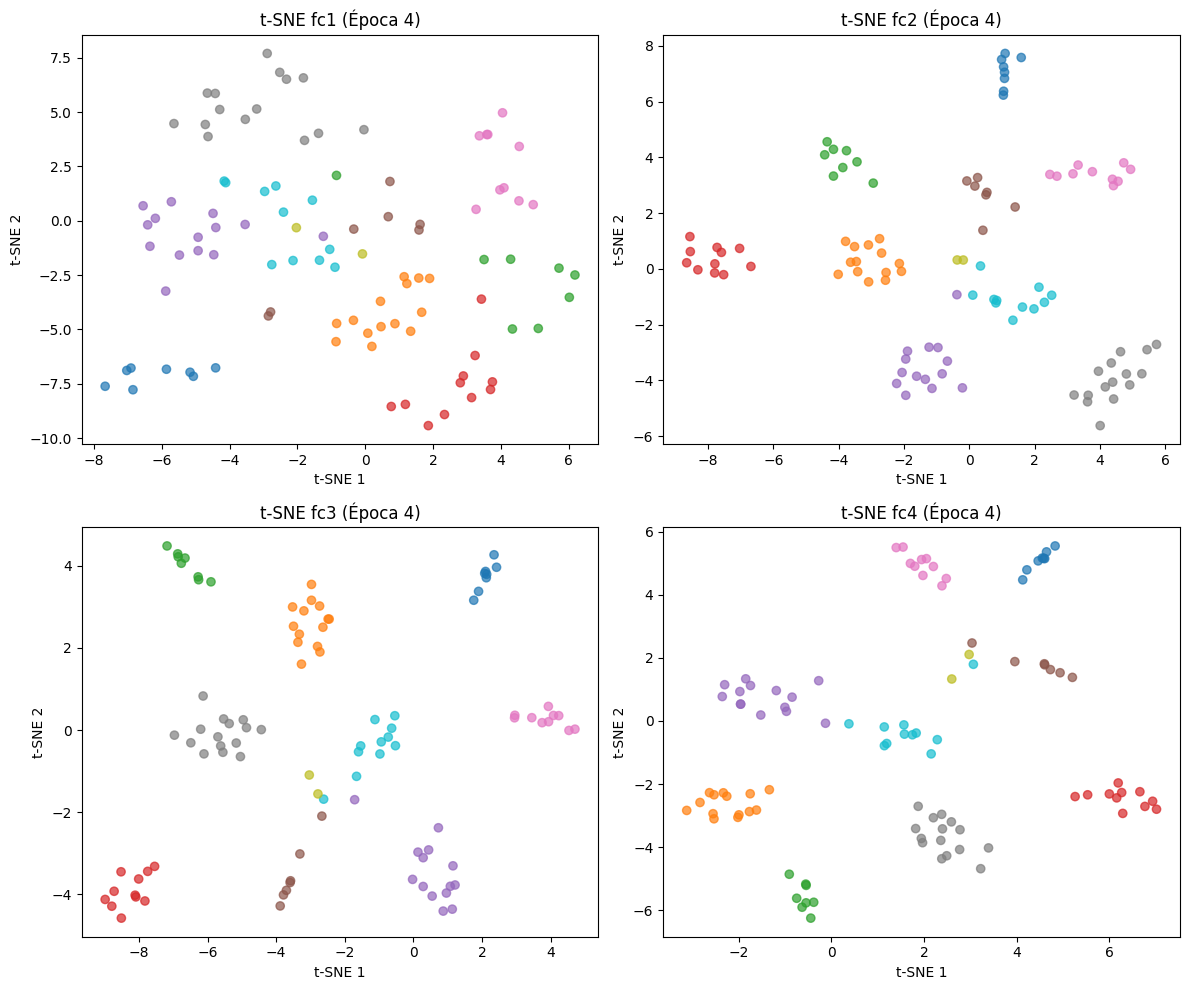

Resultados de t-SNE listos para generar JSONs


In [3]:
# Celda 3: Aplicar t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def apply_tsne(features, labels, perplexity=30, max_iter=1000, random_state=42):
    """Aplicar t-SNE a las características"""
    print(f"Aplicando t-SNE con forma de entrada: {features.shape}")
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter, random_state=random_state, verbose=1)
    embedded = tsne.fit_transform(features)
    
    return embedded

# Aplicar t-SNE para cada época y capa
tsne_results = {}
print("Aplicando t-SNE a las características...")

# Para cada época
for epoch in range(num_epochs):
    tsne_results[epoch] = {}
    print(f"\nProcesando época {epoch}...")
    
    # Para cada capa
    for layer_name in ['fc1', 'fc2', 'fc3', 'fc4']:
        print(f"  Aplicando t-SNE a capa {layer_name}")
        features = epoch_features[epoch][layer_name]
        labels = epoch_labels[epoch]
        
        # Aplicar t-SNE
        embedded = apply_tsne(features, labels)
        
        tsne_results[epoch][layer_name] = {
            'embedded': embedded,
            'labels': labels
        }

print("\nt-SNE completado para todas las épocas y capas!")

# Visualizar algunos resultados como ejemplo
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, layer_name in enumerate(['fc1', 'fc2', 'fc3', 'fc4']):
    # Usar la última época para visualización
    last_epoch = num_epochs - 1
    embedded = tsne_results[last_epoch][layer_name]['embedded']
    labels = tsne_results[last_epoch][layer_name]['labels']
    
    scatter = axes[i].scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap='tab10', alpha=0.7)
    axes[i].set_title(f't-SNE {layer_name} (Época {last_epoch})')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

print("Resultados de t-SNE listos para generar JSONs")

In [4]:
# Celda 4: Armar los JSONs en el formato correcto
import json

def create_epoch_by_epoch_json(tsne_results, layer_name="fc4"):
    """Crear JSON en formato epoch_by_epoch"""
    epoch_data = {
        "layer": layer_name,
        "epochs": []
    }
    
    for epoch in range(num_epochs):
        epoch_points = []
        embedded = tsne_results[epoch][layer_name]['embedded']
        labels = tsne_results[epoch][layer_name]['labels']
        
        for i in range(len(embedded)):
            point = {
                "id": i,
                "x": float(embedded[i, 0]),
                "y": float(embedded[i, 1]), 
                "label": int(labels[i])
            }
            epoch_points.append(point)
        
        epoch_info = {
            "epoch": epoch,
            "points": epoch_points
        }
        epoch_data["epochs"].append(epoch_info)
    
    return epoch_data

def create_layer_by_layer_json(tsne_results, target_epoch=4):
    """Crear JSON en formato layer_by_layer"""
    # Usar la última época disponible si target_epoch no existe
    actual_epoch = min(target_epoch, num_epochs - 1)
    
    layer_data = {
        "epoch": actual_epoch,
        "layers": {}
    }
    
    for layer_name in ['fc1', 'fc2', 'fc3', 'fc4']:
        layer_points = []
        embedded = tsne_results[actual_epoch][layer_name]['embedded']
        labels = tsne_results[actual_epoch][layer_name]['labels']
        
        for i in range(len(embedded)):
            point = {
                "id": i,
                "x": float(embedded[i, 0]),
                "y": float(embedded[i, 1]),
                "label": int(labels[i])
            }
            layer_points.append(point)
        
        layer_data["layers"][layer_name] = layer_points
    
    return layer_data

# Generar los JSONs
print("Generando JSONs...")

# JSON epoch by epoch para fc4
epoch_data = create_epoch_by_epoch_json(tsne_results, "fc4")

# JSON layer by layer
layer_data = create_layer_by_layer_json(tsne_results)

# Guardar JSONs
with open("../samples/tsne_epoch_by_epoch_fc4.json", "w") as f:
    json.dump(epoch_data, f, indent=2)

with open("../samples/tsne_layer_by_layer.json", "w") as f:
    json.dump(layer_data, f, indent=2)

print("JSONs guardados exitosamente!")
print(f"Epoch by epoch: {len(epoch_data['epochs'])} épocas, {len(epoch_data['epochs'][0]['points'])} puntos por época")
print(f"Layer by layer: {len(layer_data['layers'])} capas, {len(layer_data['layers']['fc1'])} puntos por capa")

# Mostrar estructura de los datos generados
print("\nEstructura del epoch_data:")
print(f"Keys: {list(epoch_data.keys())}")
print(f"Número de épocas: {len(epoch_data['epochs'])}")
print(f"Ejemplo de punto: {epoch_data['epochs'][0]['points'][0]}")

print("\nEstructura del layer_data:")
print(f"Época: {layer_data['epoch']}")
print(f"Capas: {list(layer_data['layers'].keys())}")
print(f"Ejemplo de punto fc4: {layer_data['layers']['fc4'][0]}")

# Los datos están listos para usar en las visualizaciones
epoch_data, layer_data

Generando JSONs...
JSONs guardados exitosamente!
Epoch by epoch: 5 épocas, 100 puntos por época
Layer by layer: 4 capas, 100 puntos por capa

Estructura del epoch_data:
Keys: ['layer', 'epochs']
Número de épocas: 5
Ejemplo de punto: {'id': 0, 'x': -5.702153205871582, 'y': 4.136756420135498, 'label': 7}

Estructura del layer_data:
Época: 4
Capas: ['fc1', 'fc2', 'fc3', 'fc4']
Ejemplo de punto fc4: {'id': 0, 'x': 2.3985867500305176, 'y': -3.417401075363159, 'label': 7}


({'layer': 'fc4',
  'epochs': [{'epoch': 0,
    'points': [{'id': 0,
      'x': -5.702153205871582,
      'y': 4.136756420135498,
      'label': 7},
     {'id': 1, 'x': 1.7483993768692017, 'y': 3.101025342941284, 'label': 2},
     {'id': 2, 'x': -0.5320841670036316, 'y': 4.351095676422119, 'label': 1},
     {'id': 3, 'x': -4.443207263946533, 'y': -6.463822841644287, 'label': 0},
     {'id': 4, 'x': -6.206852912902832, 'y': -1.8242523670196533, 'label': 4},
     {'id': 5, 'x': -1.062006950378418, 'y': 4.822895526885986, 'label': 1},
     {'id': 6, 'x': -5.566240310668945, 'y': -2.5825610160827637, 'label': 4},
     {'id': 7, 'x': -5.495108604431152, 'y': 0.3024594187736511, 'label': 9},
     {'id': 8, 'x': -3.574427604675293, 'y': -1.9706027507781982, 'label': 5},
     {'id': 9, 'x': -6.151341438293457, 'y': -0.11864020675420761, 'label': 9},
     {'id': 10, 'x': -4.316488265991211, 'y': -6.741227626800537, 'label': 0},
     {'id': 11, 'x': -2.7332239151000977, 'y': -4.134443759918213, 

In [5]:
# Recuperar y mostrar la imagen de un punto por su ID
import matplotlib.pyplot as plt

def show_mnist_image(image_id):
    """Mostrar la imagen MNIST correspondiente a un ID del test set"""
    img, label = test_dataset[image_id]
    # Desnormalizar: invertir Normalize((0.1307,), (0.3081,))
    img = img * 0.3081 + 0.1307
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"ID: {image_id}, Label: {label}")
    plt.axis('off')
    plt.show()



In [6]:
# Celda 6: Crear widget personalizado para visualización por épocas
from vizpro import CustomWidget
import traitlets

class CustomEpoch(CustomWidget):
    _esm = CustomWidget.createWidgetFromLocalFile(paramList=["data"], filePath=r"..\samples\d3_epoch.js")
    
    data = traitlets.Dict({}).tag(sync=True)

# Crear instancia del widget con los datos generados
plot1 = CustomEpoch(data=epoch_data)
print("Widget de épocas creado con datos de entrenamiento MNIST")
print(f"Datos cargados: {epoch_data['layer']} con {len(epoch_data['epochs'])} épocas")

Widget de épocas creado con datos de entrenamiento MNIST
Datos cargados: fc4 con 5 épocas


In [7]:
# Celda 7: Mostrar visualización por épocas
plot1

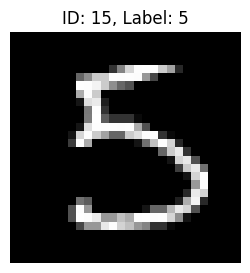

In [8]:
# Ejemplo: mostrar la imagen del punto con id=4
show_mnist_image(15)

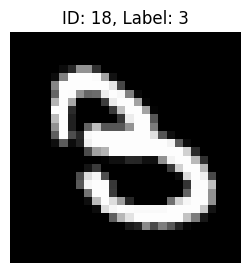

In [9]:
# Ejemplo: mostrar la imagen del punto con id=4
show_mnist_image(18)

In [10]:
# Celda 8: Crear y mostrar widget para visualización por capas
class CustomLayer(CustomWidget):
    _esm = CustomWidget.createWidgetFromLocalFile(paramList=["data"], filePath=r"..\samples\d3_layer.js")
    
    data = traitlets.Dict({}).tag(sync=True)

# Crear instancia del widget con los datos de capas
plot2 = CustomLayer(data=layer_data)
print("Widget de capas creado con datos de entrenamiento MNIST")
print(f"Datos cargados: época {layer_data['epoch']} con {len(layer_data['layers'])} capas")
print(f"Capas disponibles: {list(layer_data['layers'].keys())}")

# Mostrar el widget
plot2

Widget de capas creado con datos de entrenamiento MNIST
Datos cargados: época 4 con 4 capas
Capas disponibles: ['fc1', 'fc2', 'fc3', 'fc4']


In [11]:
from vizpro import MatrixCreator

m = MatrixCreator(3,4)
m

In [12]:
from vizpro import MatrixLayout

l = MatrixLayout(m.data,style="basic")

l.add(plot1,1)
l.add(plot2,2)
l

IndexError: list index out of range